# Advance Bank Term Deposit

## Introduction
This notebook provides a detailed analysis of customer behavior and insights into factors influencing term deposit subscription.

## Load Dataset

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load data

df=pd.read_csv('data.csv')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Customer Demographics Analysis

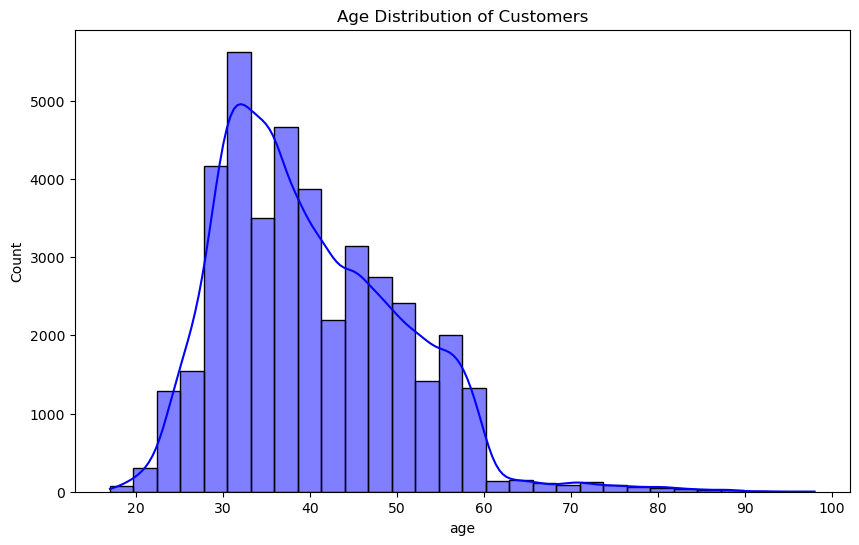

In [26]:
# Age distribution
plt.figure(figsize=(10,6))
sns.histplot(df['age'],bins=30,kde=True,color='blue')
plt.title('Age Distribution of Customers')
plt.show()

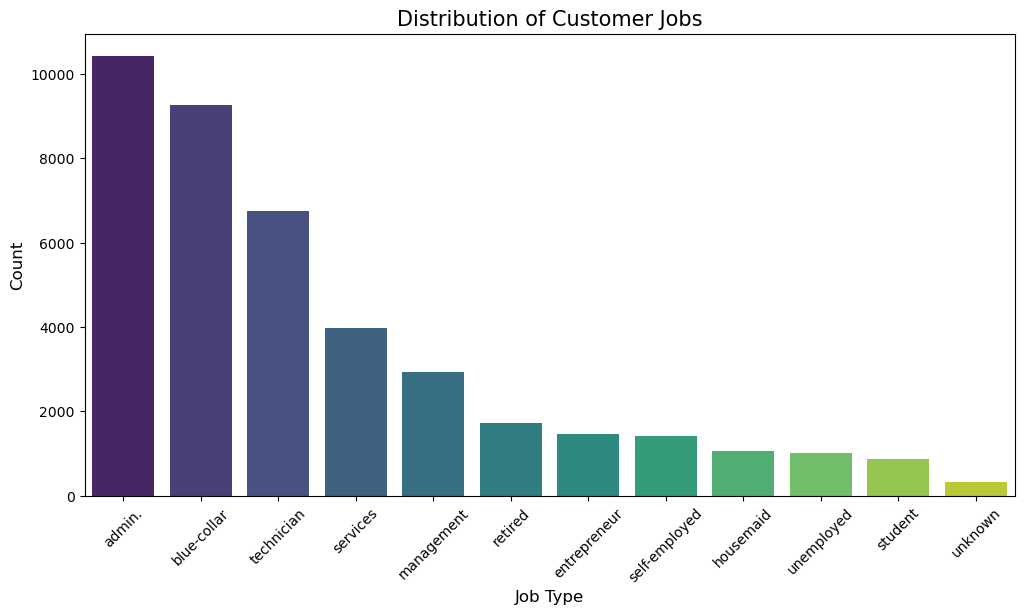

In [27]:
# Job distribution

plt.figure(figsize=(12,6))

# Get the count of each job category and sort them in descending order
job_order = df['job'].value_counts().index

# Create a count plot to visualize the frequency of each job type
sns.countplot(data=df, x='job', order=job_order, palette='viridis')

# Adding title and labels for better readability
plt.title('Distribution of Customer Jobs', fontsize=15)
plt.xlabel('Job Type', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Rotate x-axis labels by 45 degrees to prevent overlapping
plt.xticks(rotation=45)

# Display the plot
plt.show()

## Balance & Deposit Trends

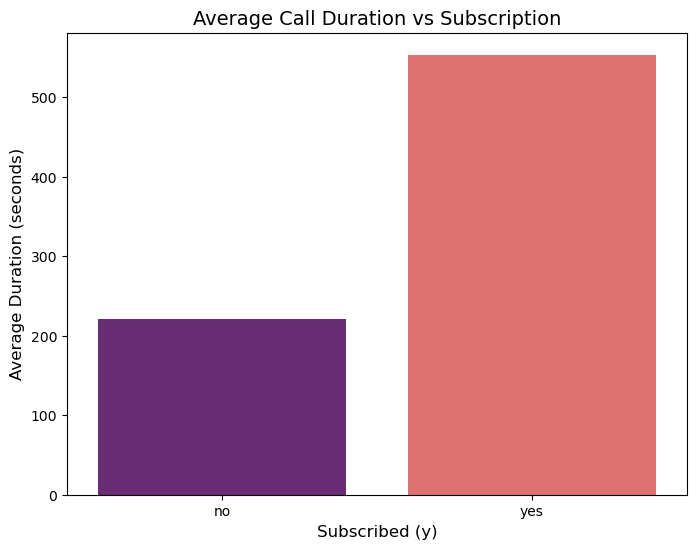

Average Duration values:
y
no     220.844807
yes    553.191164
Name: duration, dtype: float64


In [28]:
# Average balance by deposit subscription
# Average duration by deposit subscription
# Note: 'balance' is not in this dataset, so we are analyzing 'duration' instead.
plt.figure(figsize=(8,6))

# Grouping the data by subscription status ('y') and calculating the mean of 'duration'
avg_val = df.groupby('y')['duration'].mean()

# Creating a bar plot to visualize the average
sns.barplot(x=avg_val.index, y=avg_val.values, palette='magma')

# Adding labels and title
plt.title('Average Call Duration vs Subscription', fontsize=14)
plt.xlabel('Subscribed (y)', fontsize=12)
plt.ylabel('Average Duration (seconds)', fontsize=12)

# Display the plot
plt.show()

# Printing the actual mean values for reference
print("Average Duration values:")
print(avg_val)

## Campaign Effectiveness

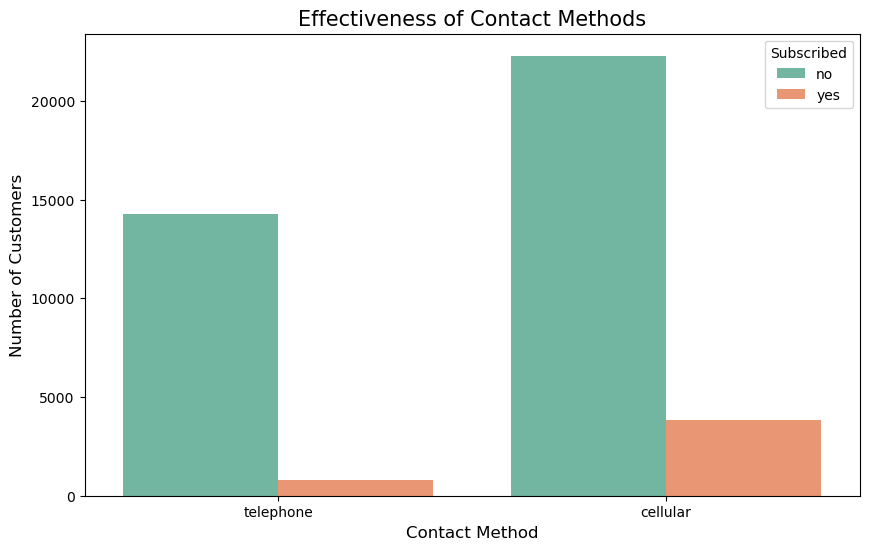

Conversion Percentage by Contact Method:
y                 no        yes
contact                        
cellular   85.262393  14.737607
telephone  94.768679   5.231321


In [29]:
# Contact method analysis
plt.figure(figsize=(10,6))

#Creating a countplot to see the distribution of 'yes' and 'no' for contact method
sns.countplot(data=df,x='contact',hue='y',palette='Set2')

#Adding titles and labels
plt.title('Effectiveness of Contact Methods', fontsize=15)
plt.xlabel('Contact Method',fontsize=12)
plt.ylabel('Number of Customers',fontsize=12)
plt.legend(title='Subscribed',loc='upper right')

#Display the plot
plt.show()

# Calculating the conversion percentage for each method
contact_conversion = pd.crosstab(df['contact'], df['y'], normalize='index') * 100
print("Conversion Percentage by Contact Method:")
print(contact_conversion)

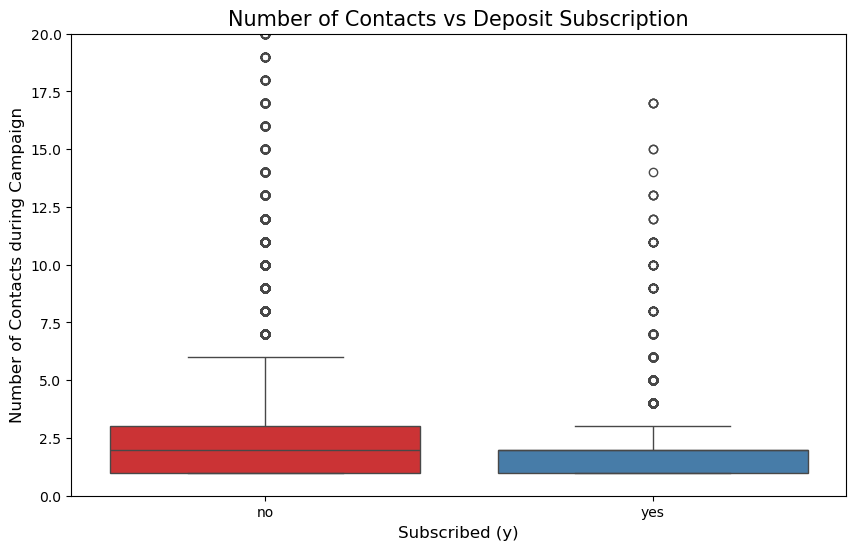

Average number of contacts per subscription status:
y
no     2.633085
yes    2.051724
Name: campaign, dtype: float64


In [30]:
# Number of contacts vs deposit subscription
plt.figure(figsize=(10,6))

#Using a boxplot to see the distribution of contacts (campaign) for 'yes' and 'no'
# We limit the y-axis to 20 to focus on the majority of the data and ignore extreme outliers
sns.boxplot(x='y',y='campaign',data = df, palette='Set1')

#Adding title and labels
plt.title('Number of Contacts vs Deposit Subscription', fontsize=15)
plt.xlabel('Subscribed (y)', fontsize=12)
plt.ylabel('Number of Contacts during Campaign',fontsize=12)

#Set y-limit to better visualize the central distribution
plt.ylim(0,20)

#Display the plot
plt.show()

# Additional insight: Average number of contacts for each group
print("Average number of contacts per subscription status:")
print(df.groupby('y')['campaign'].mean())

## Correlation Heatmap

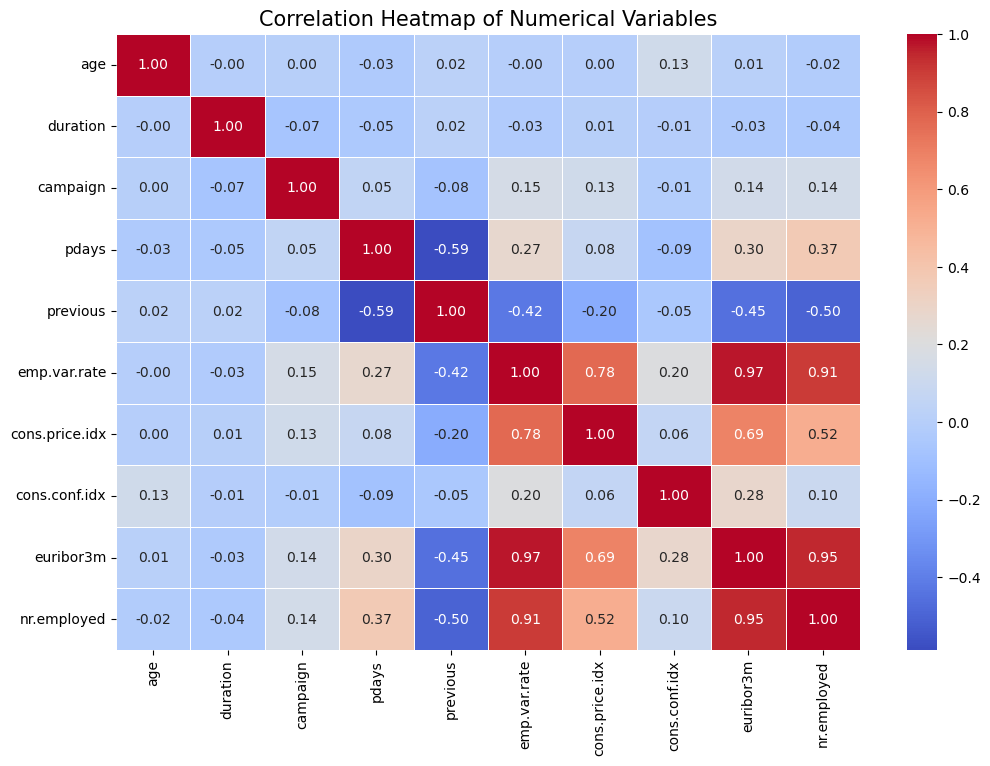

In [31]:
# Correlation of numerical variables

# Correlation of numerical variables
plt.figure(figsize=(12, 8))

# Selecting only numerical columns to calculate correlation
# This avoids errors with text columns like 'job', 'marital', etc.
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Calculating the correlation matrix
corr_matrix = numeric_df.corr()

# Creating a heatmap to visualize the relationship between numerical features
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

# Adding title to the heatmap
plt.title('Correlation Heatmap of Numerical Variables', fontsize=15)

# Display the plot using plt.show() (make sure not to use 'plot.show()')
plt.show()


## Predictive Modeling (Logistic Regression)

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

#Encode categorical variables 

# 1. Encoding the target variable 'y' (no -> 0, yes -> 1)
le = LabelEncoder()
df['y'] = le.fit_transform(df['y'])

# 2. Encoding categorical features (like job, marital, etc.) using One-Hot Encoding
# This creates dummy variables for all text columns
df_final = pd.get_dummies(df, drop_first=True)

# 3. Define Features (X) and Target (y)
X = df_final.drop('y', axis=1)
y = df_final['y']

# 4. Split the data into Training (70%) and Testing (30%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 5. Feature Scaling 
# Scaling is important for Logistic Regression to perform well
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#Model Training 

# Initialize and train the Logistic Regression model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

#Predictions

# Making predictions on the test set
y_pred = log_model.predict(X_test)

# Evaluating the model
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy Score: 0.9122764425022255

Confusion Matrix:
 [[10685   283]
 [  801   588]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.97      0.95     10968
           1       0.68      0.42      0.52      1389

    accuracy                           0.91     12357
   macro avg       0.80      0.70      0.74     12357
weighted avg       0.90      0.91      0.90     12357



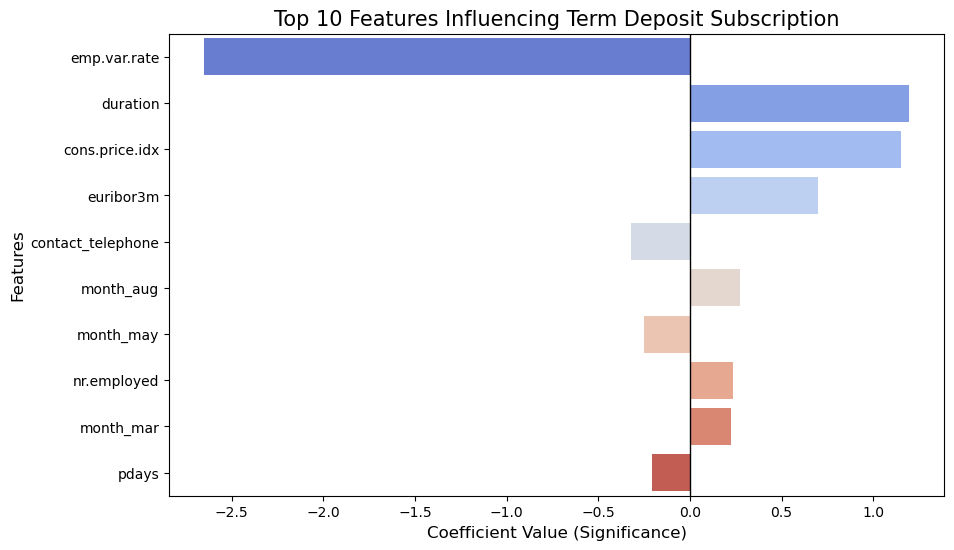

Top 5 Positive Factors (Increase Subscription):
           Feature  Importance  Abs_Importance
1         duration    1.194959        1.194959
6   cons.price.idx    1.150500        1.150500
8        euribor3m    0.701142        0.701142
38       month_aug    0.271066        0.271066
9      nr.employed    0.232663        0.232663

Top 5 Negative Factors (Decrease Subscription):
              Feature  Importance  Abs_Importance
5        emp.var.rate   -2.648432        2.648432
37  contact_telephone   -0.321600        0.321600
43          month_may   -0.249812        0.249812
3               pdays   -0.204882        0.204882


In [33]:
# Feature importance analysis
# We extract the coefficients from our trained logistic regression model
importance = log_model.coef_[0]
feature_names = X.columns

# Creating a DataFrame to organize and visualize the features and their importance scores
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance})

# We take the absolute value because both high positive and high negative 
# values are important (one increases chances, the other decreases)
feature_importance_df['Abs_Importance'] = feature_importance_df['Importance'].abs()

# Sorting to show the top 10 most influential features
feature_importance_df = feature_importance_df.sort_values(by='Abs_Importance', ascending=False).head(10)

# Plotting the feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='coolwarm')

plt.title('Top 10 Features Influencing Term Deposit Subscription', fontsize=15)
plt.xlabel('Coefficient Value (Significance)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.axvline(0, color='black', lw=1) # Adding a vertical line at zero for better contrast
plt.show()

# Print the top factors for a quick summary
print("Top 5 Positive Factors (Increase Subscription):")
print(feature_importance_df[feature_importance_df['Importance'] > 0].head(5))

print("\nTop 5 Negative Factors (Decrease Subscription):")
print(feature_importance_df[feature_importance_df['Importance'] < 0].head(5))

## Key Takeaways
- Certain age groups and job categories are more likely to subscribe.
- Higher balances correlate with higher subscription rates.
- Cellular contact is more effective than telephone.
- Campaign duration and number of contacts influence outcomes.
- Logistic regression shows which features are strongest predictors.